In [1]:
from torchvision import models
from torchvision.models import vit_b_16

print("=" * 60)

try:
    m1 = models.resnet50(weights=None)
    print("ResNet50 build success")
except Exception as e:
    print("Fail", e)

try:
    m2 = vit_b_16(weights=None)
    print("Vit-B/16 build success")
except Exception as e:
    print("Fail",e)

print("=" * 60)

ResNet50 build success
Vit-B/16 build success


In [2]:
# 1) 환경 설정 + import
import os
import gc
import random
from pathlib import Path
from collections import OrderedDict, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, recall_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from torchvision.models import vit_b_16, ViT_B_16_Weights, ResNet50_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch.backends.cudnn.benchmark = True

Device: cuda


In [3]:
print(f"현재 작업 경로: {os.getcwd()}")

test_relative = '/tf/nasw/dataset001/preprocessed/npz/fold_1_train.npz'
print(f"상대경로: {os.path.exists(test_relative)}")

현재 작업 경로: /tf/notebooks/image encoder
상대경로: True


In [4]:
#2. 경로 설정
DATA_ROOT = Path("/tf/nasw/dataset001/preprocessed/npz_v3_full_image")

FOLDS = [1, 2, 3, 4, 5]

OUTPUT_DIR = Path("./ct_cascade_models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 7
MIN_DELTA = 0.001
THRESHOLD = 0.5

print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("FOLDS:", FOLDS)

DATA_ROOT: /tf/nasw/dataset001/preprocessed/npz_v3_full_image
OUTPUT_DIR: /tf/notebooks/image encoder/ct_cascade_models
FOLDS: [1, 2, 3, 4, 5]


In [5]:
def inspect_fold_npz(fold_idx):
    train_npz_path = DATA_ROOT / f"fold_{fold_idx}_train.npz"
    val_npz_path = DATA_ROOT / f"fold_{fold_idx}_val.npz"

    print("TRAIN:", train_npz_path, train_npz_path.exits())
    print("VAL:", val_npz_path, val_npz_path.exists())

    train_npz = np.load(train_npz_path, allow_pickle=False, mmap_mode="r")
    val_npz = np.load(val_npz_path, allow_pickle=False, mmap_mode="r")

    for k in train_npz.files:
        print(f"[train] {k}: shape={train_npz[k].shape}, dtype={train_npz[k].dtype}")
    for k in val_npz.files:
        print(f"[val] {k}: shape={val_npz[k].shape}, dtype={val_npz[k].dtype}")

In [6]:
#로컬 pretrained weight 경로
LOCAL_RESNET_WEIGHTS = Path("/tf/models/pretrained/resnet50-11ad3fa6.pth")
LOCAL_VIT_WEIGHTS = Path("/tf/models/pretrained/vit_b_16-c867db91.pth")

print("LOCAL_RESNET_WEIGHTS exists:", LOCAL_RESNET_WEIGHTS.exists())
print("LOCAL_VIT_WEIGHTS exists:", LOCAL_VIT_WEIGHTS.exists())

LOCAL_RESNET_WEIGHTS exists: True
LOCAL_VIT_WEIGHTS exists: True


In [7]:
def load_local_state_dict(weight_path):
    weight_path = Path(weight_path)
    assert weight_path.exists(), f"Weight file not found: {weight_path}"

    ckpt = torch.load(weight_path, map_location="cpu")

    if isinstance(ckpt, dict) and "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
        ckpt = ckpt["state_dict"]

    return ckpt

In [8]:
def infer_malignant_type_ids(data_root, folds):
    label_set_by_type = defaultdict(set)

    for fold_idx in folds:
        for split_name in ["train", "val"]:
            npz_path = Path(data_root) / f"fold_{fold_idx}_{split_name}.npz"
            data = np.load(npz_path, allow_pickle=False, mmap_mode = "r")

            labels = data["labels"].astype(int)
            tumor_types = data["tumor_types"].astype(int)

            for y, t in zip(labels, tumor_types):
                label_set_by_type[int(t)].add(int(y))
                
        conflicts = {
            t: sorted(list(v))
            for t, v in label_set_by_type.items()
            if len(v) > 1
        }

        if len(conflicts) > 0:
            raise ValueError(
                f"tumor_type가 양성/악성 양쪽에 섞여있음: {conflicts}\n"
            )
        malignant_type_ids = sorted([
            t for t, labs in label_set_by_type.items()
            if labs == {1}
        ])

        print("malignant_type_ids:", malignant_type_ids)
        return malignant_type_ids


MALIGNANT_TYPE_IDS = infer_malignant_type_ids(DATA_ROOT, FOLDS)
MALIGNANT_MAP = {tid: i for i, tid in enumerate(MALIGNANT_TYPE_IDS)}
NUM_MALIGNANT_SUBTYPES = len(MALIGNANT_TYPE_IDS)

print("NUM_MALIGNANT_SUBTYPES:", NUM_MALIGNANT_SUBTYPES)

malignant_type_ids: [0, 1, 3, 5, 7]
NUM_MALIGNANT_SUBTYPES: 5


In [9]:
#4. Dataset 정의
class OvarianCTNPZDataset(Dataset):
    def __init__(self, npz_path):
        super().__init__()
        self.npz = np.load(npz_path, allow_pickle=False, mmap_mode="r")

        self.images = self.npz["images"]
        self.labels = self.npz["labels"].astype(np.float32)
        self.tumor_types = self.npz["tumor_types"].astype(np.int64)
        self.patient_ids = self.npz["patient_ids"] if "patient_ids" in self.npz.files else np.arange(len(self.labels))

        self.mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.images[idx]
        y = self.labels[idx]

        x = torch.from_numpy(x).float().permute(0, 3, 1, 2).contiguous()

        x = x / 255.0
        x = (x-self.mean) / self.std

        y = int(self.labels[idx])
        tumor_type = int(self.tumor_types[idx])

        if y == 1:
            if tumor_type not in MALIGNANT_MAP:
                raise ValueError(
                    f"malignant sample인데 tumor_type={tumor_type}가 MAP에 없음"
                )
            mal_subtype = MALIGNANT_MAP[tumor_type]
            mal_mask = True
        else:
            mal_subtype = -1
            mal_mask = False
            
        return {
            "image": x,
            "label": torch.tensor(y, dtype = torch.float32),
            "mal_subtype": torch.tensor(mal_subtype, dtype=torch.long),
            "mal_mask": torch.tensor(mal_mask, dtype=torch.bool),
        }

In [10]:
# fold별 dataLoader 생성
def make_fold_loaders(fold_idx):
    train_npz_path = DATA_ROOT / f"fold_{fold_idx}_train.npz"
    val_npz_path = DATA_ROOT / f"fold_{fold_idx}_val.npz"

    assert train_npz_path.exists(), f"Missing: {train_npz_path}"
    assert val_npz_path.exists(), f"Missing: {val_npz_path}"

    train_dataset = OvarianCTNPZDataset(train_npz_path)
    val_dataset = OvarianCTNPZDataset(val_npz_path)

    train_loader = DataLoader(
        train_dataset,
        batch_size = BATCH_SIZE,
        shuffle = True,
        num_workers = NUM_WORKERS,
        pin_memory = True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size = BATCH_SIZE,
        shuffle = False,
        num_workers = NUM_WORKERS,
        pin_memory = True
    )

    labels_np = train_dataset.labels.astype(int)
    neg = (labels_np == 0).sum()
    pos = (labels_np == 1).sum()
    pos_weight_value = neg / max(pos, 1)
    mal_pos_weight = torch.tensor([pos_weight_value], device = device, dtype = torch.float32)

    subtype_counts = np.zeros(NUM_MALIGNANT_SUBTYPES, dtype=np.float64)
    for y, t in zip(train_dataset.labels.astype(int), train_dataset.tumor_types.astype(int)):
        if y == 1 and t in MALIGNANT_MAP:
            subtype_counts[MALIGNANT_MAP[t]] += 1.0
            
    subtype_counts = np.maximum(subtype_counts, 1.0)
    inv = 1.0 / subtype_counts
    subtype_class_weights = inv / inv.mean()
    subtype_class_weights = torch.tensor(subtype_class_weights, dtype = torch.float32, device=device)#

    print(f"[FOLD {fold_idx}] Train benign(0): {neg}, malignant(1): {pos}, pos_weight={mal_pos_weight.item():.4f}, "
          f"subtype_class_weights = {subtype_class_weights.detach().cpu().numpy().round(4).tolist()}"
         )

    return train_loader, val_loader, mal_pos_weight, subtype_class_weights

In [11]:
class CascadeCriterion(nn.Module):
    def __init__(self, pos_weight, subtype_class_weights, subtype_loss_weight):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.ce = nn.CrossEntropyLoss(weight = subtype_class_weights)
        self.subtype_loss_weight = subtype_loss_weight
        print("subtype_loss_weight =", self.subtype_loss_weight)

    def forward(self, outputs, batch):
        labels = batch["label"].to(device).view(-1)
        mal_mask = batch["mal_mask"].to(device).view(-1)
        mal_subtype = batch["mal_subtype"].to(device).view(-1)

        loss_m = self.bce(outputs["malignancy_logits"], labels)

        if mal_mask.any():
            loss_s = self.ce(
                outputs["subtype_logits"][mal_mask],
                mal_subtype[mal_mask]
            )

        else:
            loss_s = torch.tensor(0.0, device = device)

        loss_total = loss_m + self.subtype_loss_weight * loss_s

        return {
            "loss_total": loss_total,
            "loss_malignancy": loss_m,
            "loss_subtype": loss_s

        }

In [12]:
#6 train/eval 함수

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

def compute_binary_metrics(y_true, y_prob, threshold = 0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred)
    }
    return metrics

def compute_multiclass_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    if len(y_true) == 0:
        return {
            "acc": np.nan,
            "macro_f1": np.nan,
            "cm": None
        }
    return {
        "acc": accuracy_score(y_true, y_pred),
         "cm": confusion_matrix(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division = 0),
        "macro recall": recall_score(y_true, y_pred, average="macro", zero_division=0)
    }

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_total = 0.0
    running_m = 0.0
    running_s = 0.0

    all_label = []
    all_mal_prob = []
    all_mal_pred = []

    all_mal_mask = []
    all_subtype_true = []
    all_subtype_pred = []

    for batch in loader:
        imgs = batch["image"].to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(imgs)
            loss_dict = criterion(outputs, batch)
            loss = loss_dict["loss_total"]

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        running_total += loss_dict["loss_total"].item() * bs
        running_m += loss_dict["loss_malignancy"].item() * bs
        running_s += loss_dict["loss_subtype"].item() * bs

        label_np = batch["label"].detach().cpu().numpy().astype(int).ravel()
        mal_mask_np = batch["mal_mask"].detach().cpu().numpy().astype(bool).ravel()

        mal_prob_np = torch.sigmoid(outputs["malignancy_logits"]).detach().cpu().numpy().ravel()
        mal_pred_np = (mal_prob_np >= THRESHOLD).astype(int)

        subtype_pred_np = outputs["subtype_logits"].argmax(dim=1).detach().cpu().numpy().astype(int).ravel()
        subtype_true_np = batch["mal_subtype"].detach().cpu().numpy().astype(int).ravel()

        all_label.extend(label_np.tolist())
        all_mal_prob.extend(mal_prob_np.tolist())
        all_mal_pred.extend(mal_pred_np.tolist())

        all_mal_mask.extend(mal_mask_np.tolist())
        all_subtype_true.extend(subtype_true_np.tolist())
        all_subtype_pred.extend(subtype_pred_np.tolist())

    mal_metrics = compute_binary_metrics(all_label, all_mal_prob, threshold = 0.5)

    all_label = np.asarray(all_label).astype(int)
    all_mal_pred = np.asarray(all_mal_pred).astype(int)
    all_mal_mask = np.asarray(all_mal_mask).astype(bool)
    all_subtype_true = np.asarray(all_subtype_true).astype(int)
    all_subtype_pred = np.asarray(all_subtype_pred).astype(int)

    oracle_true = all_subtype_true[all_mal_mask]
    oracle_pred = all_subtype_pred[all_mal_mask]
    subtype_oracle = compute_multiclass_metrics(oracle_true, oracle_pred)

    #Cascade subtype:
    #GT 악성 샘플 중에서, malignancy도 맞추고 subtype도 맞춰야 정답
    gt_mal_mask = (all_label == 1)
    if gt_mal_mask.sum() > 0:
        gate_recall = (all_mal_pred[gt_mal_mask] == 1).mean()
        cascade_correct = ((all_mal_pred[gt_mal_mask] == 1 ) & (oracle_pred == oracle_true)).astype(np.float32)
        subtype_cascade_acc = cascade_correct.mean()
    else:
        gate_recall = np.nan
        subtype_cascade_acc = np.nan

    metrics = {
        "loss": running_total / len(loader.dataset),
        "loss_malignancy": running_m / len(loader.dataset),
        "loss_subtype": running_s / len(loader.dataset),
        
        "acc": mal_metrics["acc"],
        "auc": mal_metrics["auc"],
        "f1":mal_metrics["f1"],
        "recall": mal_metrics["recall"],
        "cm": mal_metrics["cm"],

        "subtype_oracle_acc": subtype_oracle["acc"],
        "subtype_oracle_macro_f1": subtype_oracle["macro_f1"],
        "subtype_oracle_cm": subtype_oracle["cm"],

        "subtype_cascade_acc": float(subtype_cascade_acc),
        "subtype_gate_recall": float(gate_recall),
    }
    return metrics

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_total = 0.0
    running_m = 0.0
    running_s = 0.0

    all_label = []
    all_mal_prob = []
    all_mal_pred = []

    all_mal_mask = []
    all_subtype_true = []
    all_subtype_pred = []

    for batch in loader:
        imgs = batch["image"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(imgs)
            loss_dict = criterion(outputs, batch)

        bs = imgs.size(0)
        running_total += loss_dict["loss_total"].item() * bs
        running_m += loss_dict["loss_malignancy"].item() * bs
        running_s += loss_dict["loss_subtype"].item() * bs

        label_np = batch["label"].detach().cpu().numpy().astype(int).ravel()
        mal_mask_np = batch["mal_mask"].detach().cpu().numpy().astype(bool).ravel()

        mal_prob_np = torch.sigmoid(outputs["malignancy_logits"]).detach().cpu().numpy().ravel()
        mal_pred_np = (mal_prob_np >= THRESHOLD).astype(int)

        subtype_pred_np = outputs["subtype_logits"].argmax(dim=1).detach().cpu().numpy().astype(int).ravel()
        subtype_true_np = batch["mal_subtype"].detach().cpu().numpy().astype(int).ravel()

        all_label.extend(label_np.tolist())
        all_mal_prob.extend(mal_prob_np.tolist())
        all_mal_pred.extend(mal_pred_np.tolist())

        all_mal_mask.extend(mal_mask_np.tolist())
        all_subtype_true.extend(subtype_true_np.tolist())
        all_subtype_pred.extend(subtype_pred_np.tolist())

    mal_metrics = compute_binary_metrics(all_label, all_mal_prob, threshold = 0.5)

    all_label = np.asarray(all_label).astype(int)
    all_mal_pred = np.asarray(all_mal_pred).astype(int)
    all_mal_mask = np.asarray(all_mal_mask).astype(bool)
    all_subtype_true = np.asarray(all_subtype_true).astype(int)
    all_subtype_pred = np.asarray(all_subtype_pred).astype(int)

    oracle_true = all_subtype_true[all_mal_mask]
    oracle_pred = all_subtype_pred[all_mal_mask]
    subtype_oracle = compute_multiclass_metrics(oracle_true, oracle_pred)

    #Cascade subtype:
    #GT 악성 샘플 중에서, malignancy도 맞추고 subtype도 맞춰야 정답
    gt_mal_mask = (all_label == 1)
    if gt_mal_mask.sum() > 0:
        gate_recall = (all_mal_pred[gt_mal_mask] == 1).mean()
        cascade_correct = ((all_mal_pred[gt_mal_mask] == 1 ) & (oracle_pred == oracle_true)).astype(np.float32)
        subtype_cascade_acc = cascade_correct.mean()
    else:
        gate_recall = np.nan
        subtype_cascade_acc = np.nan

    metrics = {
        "loss": running_total / len(loader.dataset),
        "loss_malignancy": running_m / len(loader.dataset),
        "loss_subtype": running_s / len(loader.dataset),
        
        "acc": mal_metrics["acc"],
        "auc": mal_metrics["auc"],
        "f1": mal_metrics["f1"],
        "recall": mal_metrics["recall"],
        "cm": mal_metrics["cm"],

        "subtype_oracle_acc": subtype_oracle["acc"],
        "subtype_oracle_macro_f1": subtype_oracle["macro_f1"],
        "subtype_oracle_cm": subtype_oracle["cm"],

        "subtype_cascade_acc": float(subtype_cascade_acc),
        "subtype_gate_recall": float(gate_recall),
    }
    return metrics

@torch.no_grad()
def eval_confusion(model, loader, device, criterion, threshold = 0.5):
    return eval_one_epoch(model, loader, criterion, device)

In [13]:
# slice encoder + patient-level pooling wrapper

class PatientSliceAttentionClassifier(nn.Module):
    def __init__(self, encoder, feat_dim, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.encoder = encoder

        self.attn = nn.Sequential(
            nn.Linear(feat_dim, feat_dim // 2),
            nn.Tanh(),
            nn.Linear(feat_dim // 2, 1)
        )

        self.shared = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.malignancy_head = nn.Linear(hidden_dim, 1)
        
        self.subtype_head = nn.Linear(hidden_dim, NUM_MALIGNANT_SUBTYPES)

    def forward(self, x):
        # x: (B, S, C, H, W)
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feat = self.encoder(x)
        feat = feat.view(B, S, -1)

        attn_score = self.attn(feat)
        attn_weight = torch.softmax(attn_score, dim=1)
        pooled = (feat * attn_weight).sum(dim=1)

        z = self.shared(pooled)

        return {
            "malignancy_logits": self.malignancy_head(z).squeeze(1),
            "subtype_logits": self.subtype_head(z),
        }

In [14]:
#7 모델 정의
def build_resnet50_patient_model(load_pretrained=True, freeze_backbone=True, unfreeze_layer4=True, weight_path=LOCAL_RESNET_WEIGHTS):
    encoder = models.resnet50(weights=None)

    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
        
    feat_dim = encoder.fc.in_features
    encoder.fc = nn.Identity()

    if freeze_backbone:
        for p in encoder.parameters():
            p.requires_grad = False

        if unfreeze_layer4:
            for p in encoder.layer4.parameters():
                p.requires_grad = True
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.1
    )
    
    return model

def build_vit_patient_model(load_pretrained=True, weight_path=LOCAL_VIT_WEIGHTS):
    encoder = vit_b_16(weights=None)
    if load_pretrained:
        state_dict = load_local_state_dict(weight_path)
        encoder.load_state_dict(state_dict, strict = True)
    
    feat_dim = encoder.heads.head.in_features
    encoder.heads = nn.Identity()
    
    model = PatientSliceAttentionClassifier(
        encoder = encoder,
        feat_dim = feat_dim,
        hidden_dim = 512,
        dropout=0.1
    )
    return model

class CNNTransformerHybridPatient(nn.Module):
    def __init__(self, d_model=512, nhead=8, num_layers=2, dim_feedforward=1024, dropout=0.1, load_pretrained=True, freeze_backbone=True, unfreeze_layer4=True, resnet_weight_path=LOCAL_RESNET_WEIGHTS):
        super().__init__()
        backbone = models.resnet50(weights=None)
        if load_pretrained:
            state_dict = load_local_state_dict(resnet_weight_path)
            backbone.load_state_dict(state_dict, strict = True)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone

        if freeze_backbone:
            for p in self.encoder.parameters():
                p.requires_grad = False

            if unfreeze_layer4:
                for p in self.encoder.layer4.parameters():
                    p.requires_grad = True

        self.proj = nn.Linear(feat_dim, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1+8, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=0.1,
            batch_first=True,
            activation="gelu"
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers= num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.shared = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.malignancy_head = nn.Linear(512, 1)
        self.subtype_head = nn.Linear(512, NUM_MALIGNANT_SUBTYPES)

    def forward(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feat = self.encoder(x)
        feat = feat.view(B, S, -1)
        feat = self.proj(feat)

        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, feat], dim=1)
        
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]
        tokens = self.transformer(tokens)
        tokens = self.norm(tokens)

        cls_out = tokens[:, 0, :]
        z = self.shared(cls_out)

        malignancy_logits = self.malignancy_head(z).squeeze(1)

        subtype_logits = self.subtype_head(z)
        
        return {
            "malignancy_logits": malignancy_logits,
            "subtype_logits": subtype_logits
        }

        

def build_hybrid_patient_model(load_pretrained=True):
    return CNNTransformerHybridPatient(
        load_pretrained=load_pretrained,
        freeze_backbone = True,
        unfreeze_layer4 = True,
        resnet_weight_path=LOCAL_RESNET_WEIGHTS
    )

In [15]:
#8 공통 학습 함수
def fit_model(model, model_name, fold_idx, train_loader, val_loader, device, num_epochs=30, lr = 1e-4, weight_decay=1e-4, pos_weight=None, criterion=None, patience = 7, min_delta=0.001):
    model = model.to(device)
    
    if criterion is None:
        raise ValueError("cascade 모델에서는 criterion에 CascadeCriterion을 넘겨야함")
        
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr = lr,
        weight_decay = weight_decay
    )

    best_auc = -1
    best_val_loss = np.inf
    best_path = OUTPUT_DIR / f"{model_name}_fold{fold_idx}_best.pth"
    history = []
    early_stop_counter = 0

    for epoch in range(1, num_epochs+1):
        train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = eval_one_epoch(model, val_loader, criterion, device)

        row = {
            "fold": fold_idx,
            "epoch": epoch,
            
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "train_auc": train_metrics["auc"],
            "train_subtype_oracle_acc": train_metrics["subtype_oracle_acc"],
            "train_subtype_oracle_macro_f1": train_metrics["subtype_oracle_macro_f1"],
            "train_subtype_cascade_acc": train_metrics["subtype_cascade_acc"],
            
            "val_loss":val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1"],
            "val_auc": val_metrics["auc"],
            "val_recall": val_metrics["recall"],
            "val_subtype_oracle_acc": val_metrics["subtype_oracle_acc"],
            "val_subtype_oracle_macro_f1": val_metrics["subtype_oracle_macro_f1"],
            "val_subtype_cascade_acc": val_metrics["subtype_cascade_acc"],
            "val_subtype_gate_recall": val_metrics["subtype_gate_recall"],
        }
        history.append(row)

        print(
            f"[{model_name}][Fold {fold_idx}][Epoch {epoch:02d}]"
            f"train loss = {row['train_loss']:.4f}, acc={row['train_acc']:.4f}, auc={row['train_auc']:.4f},"
            f"f1 = {row['train_f1']:.4f}, recall={row['train_recall']:.4f},"
            f"subtype_oracle_f1 = {row['train_subtype_oracle_macro_f1']:.4f}, subtype_oracle_acc = {row['train_subtype_oracle_acc']:.4f} | "
            f"val loss = {row['val_loss']:.4f}, acc = {row['val_acc']:.4f}, auc = {row['val_auc']:.4f}, "
            f"f1 = {row['val_f1']:.4f}, recall={row['val_recall']:.4f}, "
            f"subtype_oracle_f1 = {row['val_subtype_oracle_macro_f1']:.4f}",
            f"subtype_cascade_acc = {row['val_subtype_cascade_acc']:.4f}"
        )

        if row["val_auc"] > best_auc:
            best_auc = row["val_auc"]

        if row["val_loss"] < best_val_loss - min_delta:
            best_val_loss = row["val_loss"]
            early_stop_counter = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> best saved by val_loss: {best_path}")
        else:
            early_stop_counter += 1
            print(f"  -> no improvement ({early_stop_counter}/{patience})")

        if early_stop_counter >= patience:
            print(f"  -> early stopping triggered at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    return model, history_df, best_path

In [16]:
# model 로드 함수
def load_model(model_type, model_path, device):
    if model_type == "resnet":
        model = build_resnet50_patient_model()
    elif model_type == "vit":
        model = build_vit_patient_model()
    elif model_type == "hybrid":
        model = build_hybrid_patient_model()
    else:
        raise ValueError("Unknown model type")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

In [17]:
def run_cv_for_model(model_name, model_type, build_fn):
    fold_results = []
    fold_histories = []

    for fold_idx in FOLDS:
        print("\n" + "=" * 80)
        print(f"Running {model_name} | Fold {fold_idx}")
        print("=" * 80)

        train_loader, val_loader, pos_weight, subtype_class_weights = make_fold_loaders(fold_idx)

        if model_type == "resnet":
            model = build_resnet50_patient_model()
        elif model_type == "vit":
            model = build_vit_patient_model()
        elif model_type == "hybrid":
            model = build_hybrid_patient_model()
        else:
            raise ValueError("Unknown model type")

        criterion = CascadeCriterion(
            pos_weight = pos_weight,
            subtype_class_weights = subtype_class_weights,
            subtype_loss_weight = 0.5
        )

        model, history_df, best_path = fit_model(
            model=model,
            model_name=model_name,
            fold_idx = fold_idx,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            num_epochs=NUM_EPOCHS,
            lr=LR,
            weight_decay=WEIGHT_DECAY,
            criterion = criterion,
            pos_weight=pos_weight,
            patience=PATIENCE,
            min_delta = MIN_DELTA
        )

        best_model = load_model(model_type, best_path, device)
        final_metrics = eval_confusion(best_model, val_loader, device, criterion, threshold=0.5)

        print(f"\n[{model_name}][Fold {fold_idx}] Final Metrics")
        print(f"malignancy auc: {final_metrics['auc']:.4f}, f1 = {final_metrics['f1']:.4f}, recall = {final_metrics['recall']:.4f}")
        print(f"subtype oracle acc: {final_metrics['subtype_oracle_acc']:.4f}, macro_f1 = {final_metrics['subtype_oracle_macro_f1']}")
        print(f"subtype cascade acc : {final_metrics['subtype_cascade_acc']:.4f}, gate_recall={final_metrics['subtype_gate_recall']:.4f}")
        print(f"Binary cm: {final_metrics['cm']}")
        print(f"Subtype oracle cm: {final_metrics['subtype_oracle_cm']}")

        fold_results.append({
            "model": model_name,
            "fold": fold_idx,
            "mal acc": final_metrics["acc"],
            "mal auc": final_metrics["auc"],
            "mal f1": final_metrics["f1"],
            "mal recall": final_metrics["recall"],
            "subtype_oracle_acc": final_metrics["subtype_oracle_acc"],
            "subtype_oracle_macro_f1": final_metrics["subtype_oracle_macro_f1"],
            "subtype_cascade_acc": final_metrics["subtype_cascade_acc"],
            "subtype_gate_recall": final_metrics["subtype_gate_recall"],
            
            "Binary cm": final_metrics["cm"],
            "subtype_oracle_cm": final_metrics["subtype_oracle_cm"],
        })

        history_df["model"] = model_name
        fold_histories.append(history_df)

        del model
        del best_model
        del train_loader
        del val_loader
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    result_df = pd.DataFrame(fold_results)
    history_df_all = pd.concat(fold_histories, ignore_index=True)
    return result_df, history_df_all

In [18]:
#9 ResNet50
print(">>> Training ResNet50...")
resnet_cv_df, resnet_history_df = run_cv_for_model(
    model_name="ResNet50",
    model_type="resnet",
    build_fn=lambda: build_resnet50_patient_model(load_pretrained=True)
)

display(resnet_cv_df)

>>> Training ResNet50...

Running ResNet50 | Fold 1
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149, subtype_class_weights = [1.6541999578475952, 0.8529000282287598, 1.1613999605178833, 1.1139999628067017, 0.2175000011920929]
subtype_loss_weight = 0.5
[ResNet50][Fold 1][Epoch 01]train loss = 1.3536, acc=0.7892, auc=0.8596,f1 = 0.6044, recall=0.7432,subtype_oracle_f1 = 0.1787, subtype_oracle_acc = 0.5360 | val loss = 0.7795, acc = 0.8207, auc = 0.9154, f1 = 0.6714, recall=0.8468, subtype_oracle_f1 = 0.1467 subtype_cascade_acc = 0.4414
  -> best saved by val_loss: ct_cascade_models/ResNet50_fold1_best.pth
[ResNet50][Fold 1][Epoch 02]train loss = 1.0687, acc=0.8677, auc=0.9418,f1 = 0.7451, recall=0.8919,subtype_oracle_f1 = 0.2958, subtype_oracle_acc = 0.5878 | val loss = 0.6454, acc = 0.8713, auc = 0.9517, f1 = 0.7519, recall=0.9009, subtype_oracle_f1 = 0.2326 subtype_cascade_acc = 0.5045
  -> best saved by val_loss: ct_cascade_models/ResNet50_fold1_best.pth
[ResNet50

,model,fold,mal acc,mal auc,mal f1,mal recall,subtype_oracle_acc,subtype_oracle_macro_f1,subtype_cascade_acc,subtype_gate_recall,Binary cm,subtype_oracle_cm
0,ResNet50,1,0.918129,0.963594,0.822034,0.873874,0.459459,0.288512,0.450450,0.873874,"[[374, 28], [14, 97]]","[[0, 3, 2, 0, 4], [0, 8, 4, 1, 7], [0, 4, 3, 1..."
1,ResNet50,2,0.881092,0.950271,0.756972,0.855856,0.549550,0.351762,0.495495,0.855856,"[[357, 45], [16, 95]]","[[0, 0, 3, 0, 3], [0, 3, 5, 1, 10], [0, 1, 8, ..."
2,ResNet50,3,0.919922,0.975433,0.829876,0.900901,0.441441,0.277652,0.405405,0.900901,"[[371, 30], [11, 100]]","[[0, 4, 1, 1, 1], [0, 12, 3, 0, 3], [0, 3, 4, ..."
3,ResNet50,4,0.923828,0.967896,0.832618,0.873874,0.522523,0.193046,0.495495,0.873874,"[[376, 25], [14, 97]]","[[0, 1, 0, 0, 11], [0, 4, 0, 0, 6], [0, 4, 0, ..."
4,ResNet50,5,0.882812,0.945923,0.761905,0.864865,0.567568,0.318110,0.531532,0.864865,"[[356, 45], [15, 96]]","[[0, 0, 2, 4, 2], [0, 2, 3, 3, 9], [0, 0, 2, 3..."


In [19]:
#10 vit
print(">>> Training VIT...")
vit_cv_df, vit_history_df = run_cv_for_model(
    model_name="ViT-B16",
    model_type="vit",
    build_fn=lambda: build_vit_patient_model(load_pretrained=True)
)

display(vit_cv_df)

>>> Training VIT...

Running ViT-B16 | Fold 1
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149, subtype_class_weights = [1.6541999578475952, 0.8529000282287598, 1.1613999605178833, 1.1139999628067017, 0.2175000011920929]
subtype_loss_weight = 0.5
[ViT-B16][Fold 1][Epoch 01]train loss = 1.7321, acc=0.5237, auc=0.5292,f1 = 0.3068, recall=0.4865,subtype_oracle_f1 = 0.1815, subtype_oracle_acc = 0.5158 | val loss = 1.2688, acc = 0.2164, auc = 0.7161, f1 = 0.3558, recall=1.0000, subtype_oracle_f1 = 0.1404 subtype_cascade_acc = 0.5405
  -> best saved by val_loss: ct_cascade_models/ViT-B16_fold1_best.pth
[ViT-B16][Fold 1][Epoch 02]train loss = 1.7198, acc=0.5051, auc=0.5126,f1 = 0.3130, recall=0.5203,subtype_oracle_f1 = 0.1445, subtype_oracle_acc = 0.5653 | val loss = 1.2640, acc = 0.7836, auc = 0.6631, f1 = 0.0000, recall=0.0000, subtype_oracle_f1 = 0.1404 subtype_cascade_acc = 0.0000
  -> best saved by val_loss: ct_cascade_models/ViT-B16_fold1_best.pth
[ViT-B16][Fold 1][E

,model,fold,mal acc,mal auc,mal f1,mal recall,subtype_oracle_acc,subtype_oracle_macro_f1,subtype_cascade_acc,subtype_gate_recall,Binary cm,subtype_oracle_cm
0,ViT-B16,1,0.575049,0.734716,0.475962,0.891892,0.522523,0.137278,0.468468,0.891892,"[[196, 206], [12, 99]]","[[0, 0, 0, 0, 9], [0, 0, 0, 0, 20], [0, 0, 0, ..."
1,ViT-B16,2,0.692008,0.806452,0.532544,0.810811,0.513514,0.135714,0.405405,0.810811,"[[265, 137], [21, 90]]","[[0, 0, 0, 0, 6], [0, 0, 0, 0, 19], [0, 0, 0, ..."
2,ViT-B16,3,0.566406,0.752511,0.481308,0.927928,0.594595,0.149153,0.540541,0.927928,"[[187, 214], [8, 103]]","[[0, 0, 0, 0, 7], [0, 0, 0, 0, 18], [0, 0, 0, ..."
3,ViT-B16,4,0.779297,0.855485,0.594982,0.747748,0.459459,0.143847,0.378378,0.747748,"[[316, 85], [28, 83]]","[[0, 2, 1, 0, 9], [0, 1, 1, 0, 8], [0, 0, 0, 0..."
4,ViT-B16,5,0.425781,0.685707,0.425781,0.981982,0.567568,0.144828,0.558559,0.981982,"[[109, 292], [2, 109]]","[[0, 0, 0, 0, 8], [0, 0, 0, 0, 17], [0, 0, 0, ..."


In [20]:
#11 Hybrid
print(">>> Training Hybrid...")
hybrid_cv_df, hybrid_history_df = run_cv_for_model(
    model_name="Hybrid",
    model_type="hybrid",
    build_fn=lambda: build_hybrid_patient_model(load_pretrained=True)
)

display(hybrid_cv_df)

>>> Training Hybrid...

Running Hybrid | Fold 1
[FOLD 1] Train benign(0): 1605, malignant(1): 444, pos_weight=3.6149, subtype_class_weights = [1.6541999578475952, 0.8529000282287598, 1.1613999605178833, 1.1139999628067017, 0.2175000011920929]
subtype_loss_weight = 0.5
[Hybrid][Fold 1][Epoch 01]train loss = 1.2867, acc=0.8077, auc=0.8884,f1 = 0.6463, recall=0.8108,subtype_oracle_f1 = 0.2404, subtype_oracle_acc = 0.5045 | val loss = 0.6682, acc = 0.8246, auc = 0.9601, f1 = 0.6980, recall=0.9369, subtype_oracle_f1 = 0.1897 subtype_cascade_acc = 0.3784
  -> best saved by val_loss: ct_cascade_models/Hybrid_fold1_best.pth
[Hybrid][Fold 1][Epoch 02]train loss = 0.9656, acc=0.9014, auc=0.9559,f1 = 0.8008, recall=0.9144,subtype_oracle_f1 = 0.3372, subtype_oracle_acc = 0.5631 | val loss = 0.6526, acc = 0.9220, auc = 0.9692, f1 = 0.8165, recall=0.8018, subtype_oracle_f1 = 0.2007 subtype_cascade_acc = 0.4144
  -> best saved by val_loss: ct_cascade_models/Hybrid_fold1_best.pth
[Hybrid][Fold 1][Epoc

,model,fold,mal acc,mal auc,mal f1,mal recall,subtype_oracle_acc,subtype_oracle_macro_f1,subtype_cascade_acc,subtype_gate_recall,Binary cm,subtype_oracle_cm
0,Hybrid,1,0.933723,0.970048,0.852174,0.882883,0.306306,0.217714,0.270270,0.882883,"[[381, 21], [13, 98]]","[[1, 3, 0, 1, 4], [0, 12, 0, 2, 6], [0, 6, 0, ..."
1,Hybrid,2,0.922027,0.972424,0.829060,0.873874,0.558559,0.267609,0.495495,0.873874,"[[376, 26], [14, 97]]","[[0, 0, 1, 1, 4], [0, 0, 1, 5, 13], [0, 0, 1, ..."
2,Hybrid,3,0.890625,0.969648,0.791045,0.954955,0.594595,0.181905,0.576577,0.954955,"[[350, 51], [5, 106]]","[[0, 0, 0, 0, 7], [0, 0, 0, 0, 18], [0, 0, 1, ..."
3,Hybrid,4,0.875000,0.965087,0.764706,0.936937,0.468468,0.238583,0.441441,0.936937,"[[344, 57], [7, 104]]","[[0, 3, 1, 0, 8], [0, 5, 1, 2, 2], [0, 3, 3, 5..."
4,Hybrid,5,0.884766,0.955090,0.770428,0.891892,0.675676,0.451575,0.621622,0.891892,"[[354, 47], [12, 99]]","[[0, 1, 2, 1, 4], [0, 7, 1, 1, 8], [0, 1, 6, 0..."


In [21]:
#13 5-fold 평균 +- 표준편차

all_cv_df = pd.concat([resnet_cv_df, vit_cv_df, hybrid_cv_df], ignore_index=True)

summary_df = (
    all_cv_df.groupby("model")[["mal auc", "mal f1", "mal recall", "subtype_oracle_acc", "subtype_oracle_macro_f1", "subtype_cascade_acc", "subtype_gate_recall"]]
    .agg(["mean", "std"])
)

display(summary_df)

mal auc              mal f1           mal recall            \
              mean       std      mean       std       mean       std   
model                                                                   
Hybrid    0.966459  0.006888  0.801482  0.037934   0.908108  0.035697   
ResNet50  0.960623  0.012291  0.800681  0.037889   0.873874  0.016854   
ViT-B16   0.766974  0.065664  0.502116  0.064214   0.872072  0.093277   

         subtype_oracle_acc           subtype_oracle_macro_f1            \
                       mean       std                    mean       std   
model                                                                     
Hybrid             0.520721  0.141071                0.271477  0.105411   
ResNet50           0.508108  0.055389                0.285817  0.059313   
ViT-B16            0.531532  0.052143                0.142164  0.005573   

         subtype_cascade_acc           subtype_gate_recall            
                        mean       std                mean       std  
model                                                                 
Hybrid              0.481081  0.137014            0.908108  0.035697  
ResNet50            0.475676  0.048682            0.873874  0.016854  
ViT-B16             0.470270  0.079667            0.872072  0.093277

In [22]:
import matplotlib.pyplot as plt

def plot_one_model_by_fold(history_df, model_name):
    folds = sorted(history_df["fold"].unique())

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1,2,1)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold['train_loss'], linestyle='--', alpha = 0.7, label=f'Fold{fold} Train')
        plt.plot(df_fold["epoch"], df_fold['val_loss'], alpha = 0.7, label=f'Fold{fold} Val')
    plt.title(f"{model_name} - Loss by Fold")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(fontsize=8)

    plt.subplot(1, 2, 2)
    for fold in folds:
        df_fold = history_df[history_df["fold"] == fold].sort_values("epoch")
        plt.plot(df_fold["epoch"], df_fold["val_auc"], alpha = 0.8, label = f"Fold{fold}")

    plt.title(f"{model_name} - Val ROC-AUC by Fold")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

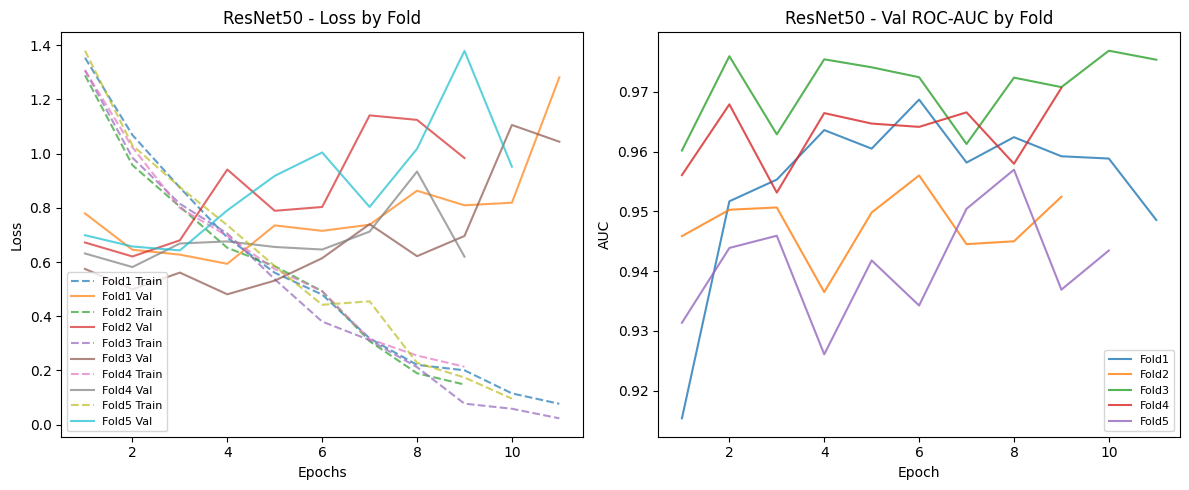

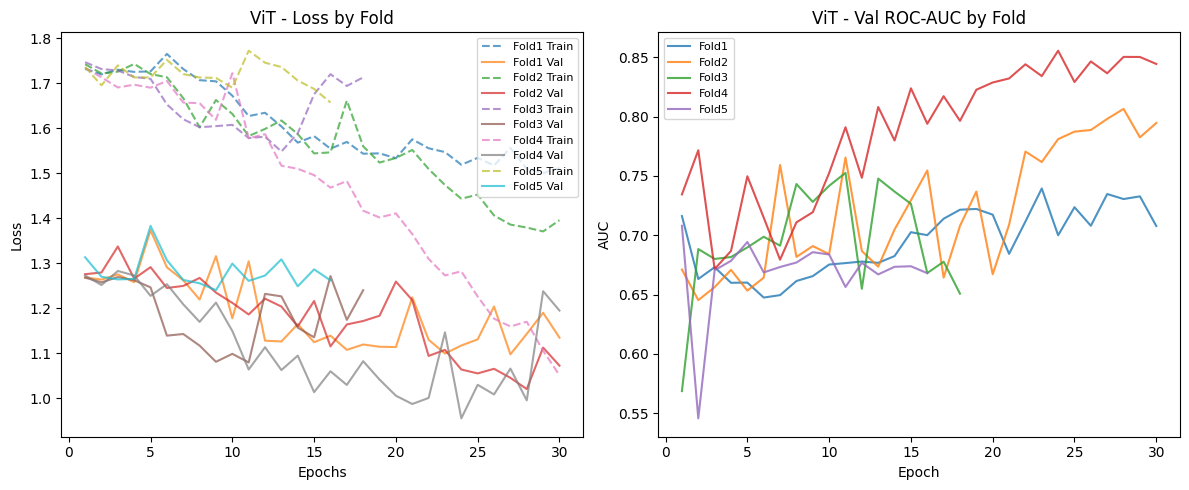

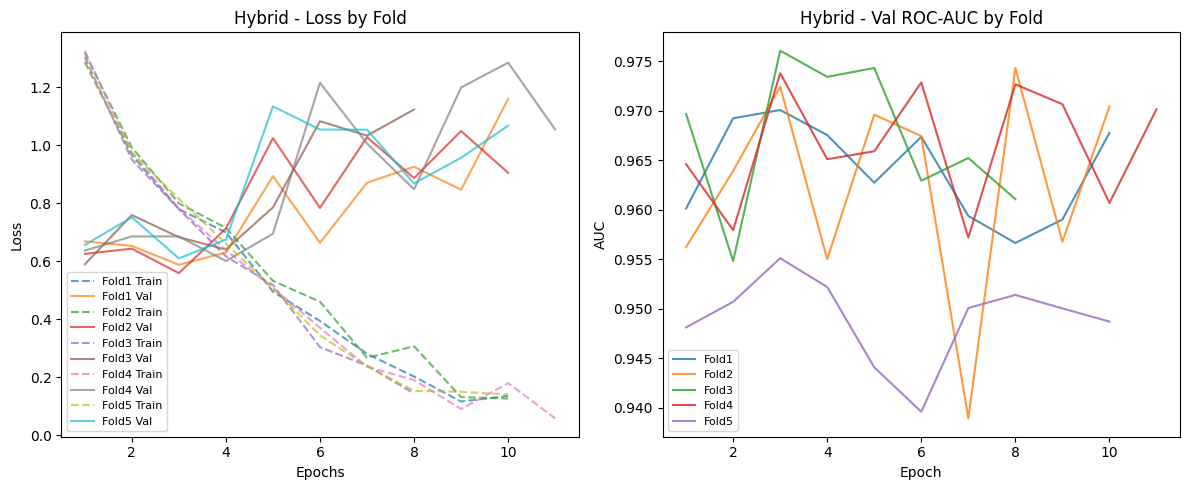

In [23]:
plot_one_model_by_fold(resnet_history_df, "ResNet50")
plot_one_model_by_fold(vit_history_df, "ViT")
plot_one_model_by_fold(hybrid_history_df, "Hybrid")